In [2]:
from m1k_utils import SMU
smu=SMU()
print(smu)

SMU:
  [0] Device 20322050544A4D39203130323930303 | FW:2.17 HW:F


In [3]:
from pysmu import Mode
dev=smu.devices[0]
ch_a=dev.ch_a
ch_a._ch.mode=Mode.SVMI
print(ch_a)

Channel(mode=Mode.SVMI)


In [8]:
ch_a._ch.flush()
ch_a._ch.write([1],-1)


In [5]:
smu.start(0)

[SMU] Session started


In [6]:
ch_a.dc(5)

In [9]:

import time



ch_a.dev.flush(-1,True)
time.sleep(0.02)
l=ch_a._ch.read(10)
print(l)
len(l)

[(0.9722137451171875, 9.307861182605848e-05), (0.972137451171875, 1.678466833254788e-05), (0.9722137451171875, 4.730224463855848e-05), (0.9720611572265625, 7.019042823230848e-05), (0.9720611572265625, 2.441406286379788e-05), (0.972137451171875, 5.493163916980848e-05), (0.972137451171875, -6.10351571594947e-06), (0.9722137451171875, 3.967285010730848e-05), (0.972137451171875, 1.678466833254788e-05), (0.9722137451171875, 8.544921729480848e-05)]


10

In [10]:
k=ch_a.dcr()
print(k)

0.9721733093261719


In [11]:
import time
import numpy as np
import matplotlib.pyplot as plt

def calibrate_write_read(channel, v_start=0, v_stop=5, steps=99, samples=100, settle_s=0.05):
    write_values = np.linspace(v_start, v_stop, steps)
    read_values = []

    for v in write_values:
        channel.dc(float(v))
        time.sleep(settle_s)
        read_values.append(float(channel.dcr(samples)))

    return write_values, np.array(read_values, dtype=float)

write_v, read_v = calibrate_write_read(ch_a)

# Linear calibration model: read ~= gain * write + offset
gain, offset = np.polyfit(write_v, read_v, 1)
fit_v = gain * write_v + offset
rmse = float(np.sqrt(np.mean((read_v - fit_v) ** 2)))

print(f"gain   : {gain:.6f}")
print(f"offset : {offset:.6f} V")
print(f"rmse   : {rmse:.6f} V")
print()
print("write_V    read_V")
for w, r in zip(write_v, read_v):
    print(f"{w:7.3f} -> {r:7.3f}")

gain   : 0.972871
offset : -0.000446 V
rmse   : 0.000463 V

write_V    read_V
  0.000 ->   0.004
  0.051 ->   0.049
  0.102 ->   0.099
  0.153 ->   0.148
  0.204 ->   0.198
  0.255 ->   0.247
  0.306 ->   0.297
  0.357 ->   0.347
  0.408 ->   0.396
  0.459 ->   0.446
  0.510 ->   0.496
  0.561 ->   0.545
  0.612 ->   0.595
  0.663 ->   0.645
  0.714 ->   0.694
  0.765 ->   0.744
  0.816 ->   0.794
  0.867 ->   0.843
  0.918 ->   0.893
  0.969 ->   0.942
  1.020 ->   0.992
  1.071 ->   1.042
  1.122 ->   1.091
  1.173 ->   1.141
  1.224 ->   1.191
  1.276 ->   1.240
  1.327 ->   1.290
  1.378 ->   1.340
  1.429 ->   1.389
  1.480 ->   1.439
  1.531 ->   1.489
  1.582 ->   1.538
  1.633 ->   1.588
  1.684 ->   1.638
  1.735 ->   1.687
  1.786 ->   1.737
  1.837 ->   1.787
  1.888 ->   1.836
  1.939 ->   1.886
  1.990 ->   1.935
  2.041 ->   1.985
  2.092 ->   2.035
  2.143 ->   2.084
  2.194 ->   2.134
  2.245 ->   2.184
  2.296 ->   2.233
  2.347 ->   2.283
  2.398 ->   2.332
  2.449 ->

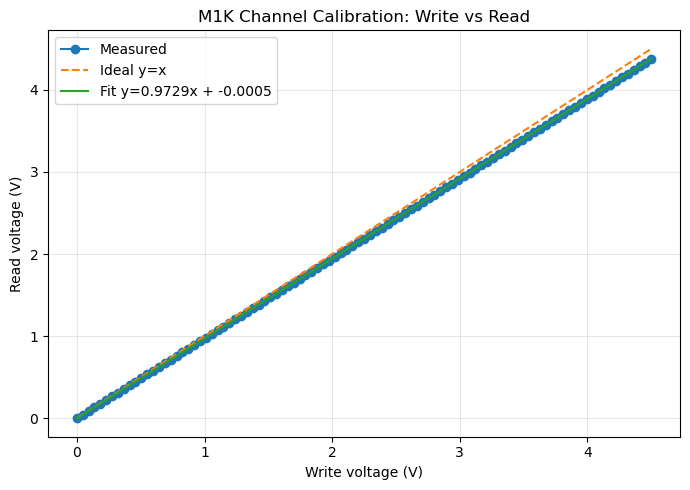

In [20]:
plt.figure(figsize=(7, 5))
plt.plot(write_v, read_v, "o-", label="Measured")
plt.plot(write_v, write_v, "--", label="Ideal y=x")
plt.plot(write_v, fit_v, label=f"Fit y={gain:.4f}x + {offset:.4f}")
plt.xlabel("Write voltage (V)")
plt.ylabel("Read voltage (V)")
plt.title("M1K Channel Calibration: Write vs Read")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Interactive calibration: write voltage vs external DMM
import time
import numpy as np

def calibrate_write_vs_dmm(channel, v_start=0.0, v_stop=5.0, steps=21, samples=100, settle_s=0.10):
    write_values = np.linspace(v_start, v_stop, steps)
    read_values = []
    dmm_values = []

    print("Type external DMM voltage for each setpoint.")
    print("Press Enter with no value to stop early.\n")

    for idx, v in enumerate(write_values, start=1):
        channel.dc(float(v))
        time.sleep(settle_s)
        read_v = float(channel.dcr(samples))
        prompt = f"[{idx}/{len(write_values)}] Set={v:.4f} V, internal={read_v:.4f} V, DMM="
        raw = input(prompt).strip()
        if raw == "":
            print("Stopping early by user request.")
            break
        try:
            dmm_v = float(raw)
        except ValueError:
            print("Invalid number, repeat this point.")
            channel.dc(float(v))
            time.sleep(settle_s)
            read_v = float(channel.dcr(samples))
            raw = input(prompt).strip()
            dmm_v = float(raw)

        read_values.append(read_v)
        dmm_values.append(dmm_v)

    used_write = write_values[:len(dmm_values)]
    used_read = np.array(read_values, dtype=float)
    used_dmm = np.array(dmm_values, dtype=float)

    if len(used_dmm) < 2:
        raise RuntimeError("Need at least 2 points for calibration fit.")

    # DMM ~= a*write + b
    gain_w2d, off_w2d = np.polyfit(used_write, used_dmm, 1)
    fit_dmm_from_write = gain_w2d * used_write + off_w2d
    rmse_w2d = float(np.sqrt(np.mean((used_dmm - fit_dmm_from_write) ** 2)))

    # DMM ~= c*internal_read + d
    gain_r2d, off_r2d = np.polyfit(used_read, used_dmm, 1)
    fit_dmm_from_read = gain_r2d * used_read + off_r2d
    rmse_r2d = float(np.sqrt(np.mean((used_dmm - fit_dmm_from_read) ** 2)))

    print("\nCalibration summary")
    print(f"DMM ~= {gain_w2d:.6f} * write + {off_w2d:.6f}   (RMSE={rmse_w2d:.6f} V)")
    print(f"DMM ~= {gain_r2d:.6f} * read  + {off_r2d:.6f}   (RMSE={rmse_r2d:.6f} V)")

    return {
        "write_v": used_write,
        "read_v": used_read,
        "dmm_v": used_dmm,
        "gain_w2d": float(gain_w2d),
        "off_w2d": float(off_w2d),
        "gain_r2d": float(gain_r2d),
        "off_r2d": float(off_r2d),
        "fit_w2d": fit_dmm_from_write,
        "fit_r2d": fit_dmm_from_read,
        "rmse_w2d": rmse_w2d,
        "rmse_r2d": rmse_r2d,
    }

cal_dmm = calibrate_write_vs_dmm(ch_a, v_start=0.0, v_stop=5.0, steps=21, samples=100, settle_s=0.10)

In [ ]:
import matplotlib.pyplot as plt

write_v = cal_dmm["write_v"]
read_v = cal_dmm["read_v"]
dmm_v = cal_dmm["dmm_v"]

plt.figure(figsize=(8, 5))
plt.plot(write_v, dmm_v, "o", label="DMM vs write (points)")
plt.plot(write_v, cal_dmm["fit_w2d"], "-", label=f"Fit: DMM={cal_dmm['gain_w2d']:.4f}*write+{cal_dmm['off_w2d']:.4f}")
plt.plot(write_v, write_v, "--", alpha=0.6, label="Ideal y=x")
plt.xlabel("Write voltage (V)")
plt.ylabel("External DMM voltage (V)")
plt.title("Write vs External DMM")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(read_v, dmm_v, "o", label="DMM vs internal read (points)")
x = np.linspace(float(np.min(read_v)), float(np.max(read_v)), 100)
plt.plot(x, cal_dmm["gain_r2d"] * x + cal_dmm["off_r2d"], "-", label=f"Fit: DMM={cal_dmm['gain_r2d']:.4f}*read+{cal_dmm['off_r2d']:.4f}")
plt.xlabel("Internal read voltage (V)")
plt.ylabel("External DMM voltage (V)")
plt.title("Internal Read vs External DMM")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()